
================ AMYLOID =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4727 entries, 0 to 4726
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   qc_flag           4727 non-null   int64  
 1   TRACER            4727 non-null   object 
 2   IMAGE_RESOLUTION  4727 non-null   object 
 3   PROCESSDATE       4715 non-null   object 
 4   AMYLOID_STATUS    4637 non-null   float64
 5   CENTILOIDS        4715 non-null   float64
 6   SUMMARY_SUVR      4715 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 258.6+ KB
None

================ TAU =================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2489 entries, 0 to 2488
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   qc_flag             2489 non-null   int64  
 1   TRACER              2489 non-null   object 
 2   IMAGE_RESOL

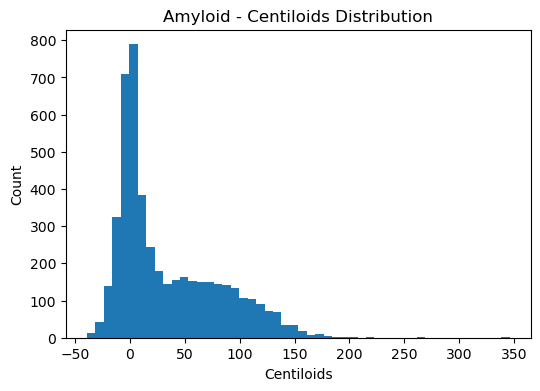

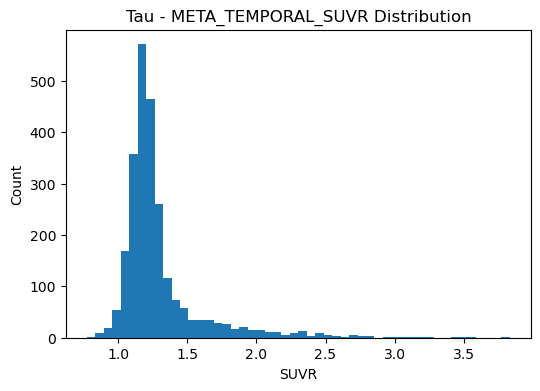

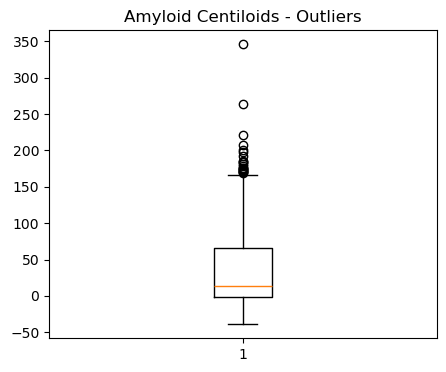

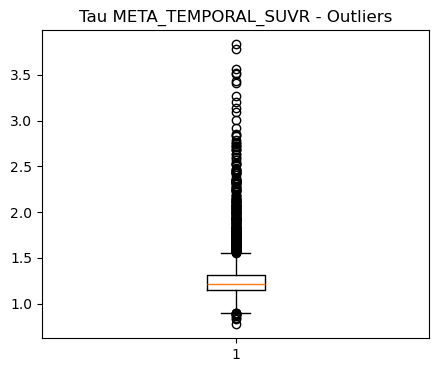

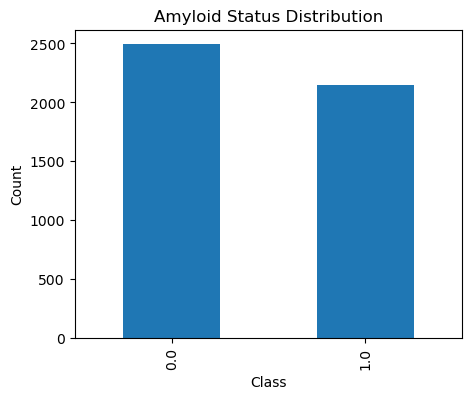

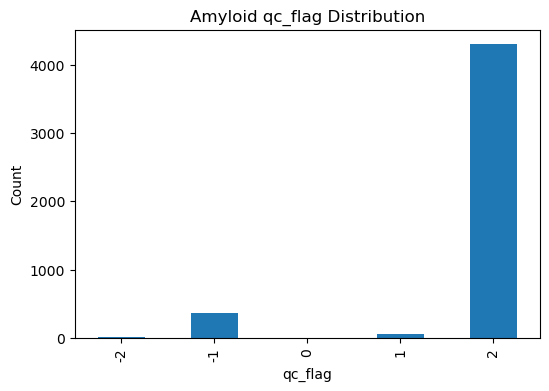

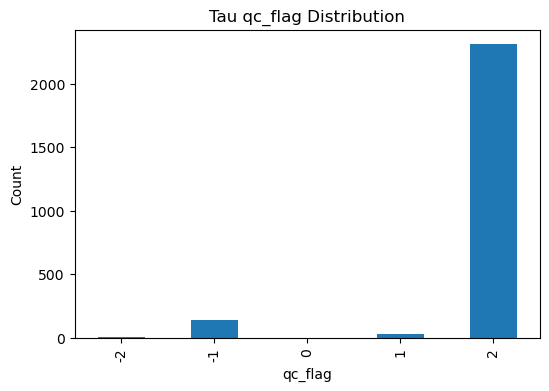

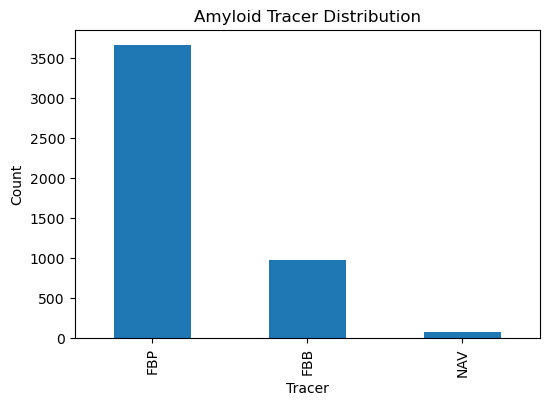

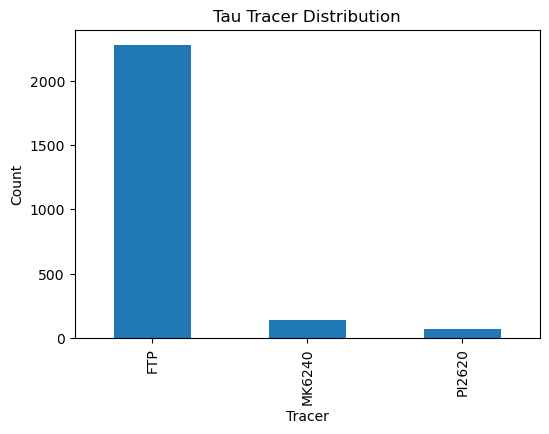

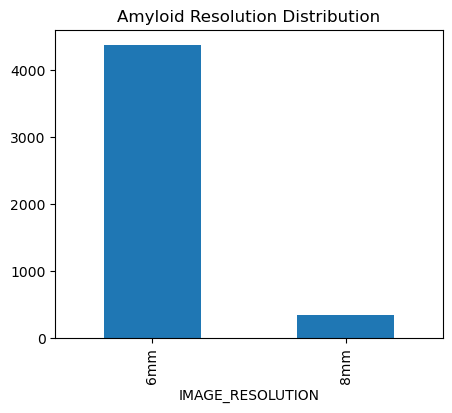

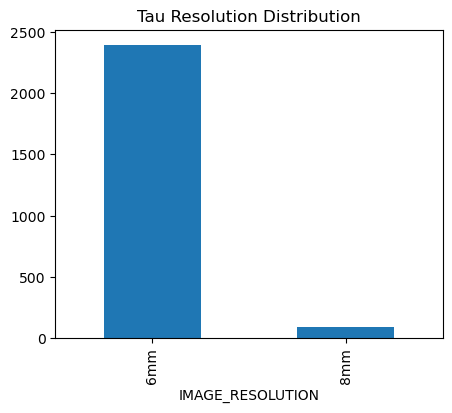


Amyloid duplicate rows: 6
Tau duplicate rows: 0


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# =========================================================
# LOAD TABLES
# =========================================================
amy = pd.read_csv("Tables_PET/UCBERKELEY_AMY_6MM.csv")
tau = pd.read_csv("Tables_PET/UCBERKELEY_TAU_6MM.csv")

# =========================================================
# INTERESTING COLUMNS
# =========================================================
amy_cols = ["qc_flag",  "TRACER",  "IMAGE_RESOLUTION",  "PROCESSDATE",  "AMYLOID_STATUS",  "CENTILOIDS",  "SUMMARY_SUVR"]
tau_cols = ["qc_flag",  "TRACER",  "IMAGE_RESOLUTION",  "PROCESSDATE",  "META_TEMPORAL_SUVR"]

# =========================================================
# BASIC OVERVIEW
# =========================================================
print("\n================ AMYLOID =================")
print(amy[amy_cols].info())
print("\n================ TAU =================")
print(tau[tau_cols].info())

# =========================================================
# MISSING VALUES
# =========================================================
print("\n===== AMYLOID MISSING VALUES =====")
print(amy[amy_cols].isnull().sum())
print("\n===== TAU MISSING VALUES =====")
print(tau[tau_cols].isnull().sum())

# =========================================================
# UNIQUE VALUES
# =========================================================
for col in ["qc_flag", "TRACER", "IMAGE_RESOLUTION", "AMYLOID_STATUS"]:
    print(f"\nAMYLOID -> {col}")
    print(amy[col].value_counts(dropna=False))
for col in ["qc_flag", "TRACER", "IMAGE_RESOLUTION"]:
    print(f"\nTAU -> {col}")
    print(tau[col].value_counts(dropna=False))

# =========================================================
# NUMERICAL STATS
# =========================================================
print("\n===== AMYLOID NUMERICAL STATS =====")
print(amy[["CENTILOIDS"]].describe())

print("\n===== TAU NUMERICAL STATS =====")
print(tau[["META_TEMPORAL_SUVR"]].describe())

# =========================================================
# HISTOGRAMS
# =========================================================
# Amyloid - Centiloids
plt.figure(figsize=(6,4))
plt.hist(amy["CENTILOIDS"].dropna(), bins=50)
plt.title("Amyloid - Centiloids Distribution")
plt.xlabel("Centiloids")
plt.ylabel("Count")
plt.show()
# Tau - META_TEMPORAL_SUVR
plt.figure(figsize=(6,4))
plt.hist(tau["META_TEMPORAL_SUVR"].dropna(), bins=50)
plt.title("Tau - META_TEMPORAL_SUVR Distribution")
plt.xlabel("SUVR")
plt.ylabel("Count")
plt.show()

# =========================================================
# BOX PLOTS (OUTLIERS)
# =========================================================
plt.figure(figsize=(5,4))
plt.boxplot(amy["CENTILOIDS"].dropna())
plt.title("Amyloid Centiloids - Outliers")
plt.show()

plt.figure(figsize=(5,4))
plt.boxplot(tau["META_TEMPORAL_SUVR"].dropna())
plt.title("Tau META_TEMPORAL_SUVR - Outliers")
plt.show()

# =========================================================
# CLASS DISTRIBUTION
# =========================================================
plt.figure(figsize=(5,4))
amy["AMYLOID_STATUS"].value_counts().sort_index().plot(kind="bar")
plt.title("Amyloid Status Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# =========================================================
# QC DISTRIBUTION
# =========================================================
plt.figure(figsize=(6,4))
amy["qc_flag"].value_counts().sort_index().plot(kind="bar")
plt.title("Amyloid qc_flag Distribution")
plt.xlabel("qc_flag")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
tau["qc_flag"].value_counts().sort_index().plot(kind="bar")
plt.title("Tau qc_flag Distribution")
plt.xlabel("qc_flag")
plt.ylabel("Count")
plt.show()

# =========================================================
# TRACER DISTRIBUTION
# =========================================================
plt.figure(figsize=(6,4))
amy["TRACER"].value_counts().plot(kind="bar")
plt.title("Amyloid Tracer Distribution")
plt.xlabel("Tracer")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
tau["TRACER"].value_counts().plot(kind="bar")
plt.title("Tau Tracer Distribution")
plt.xlabel("Tracer")
plt.ylabel("Count")
plt.show()

# =========================================================
# RESOLUTION DISTRIBUTION
# =========================================================
plt.figure(figsize=(5,4))
amy["IMAGE_RESOLUTION"].value_counts().plot(kind="bar")
plt.title("Amyloid Resolution Distribution")
plt.show()

plt.figure(figsize=(5,4))
tau["IMAGE_RESOLUTION"].value_counts().plot(kind="bar")
plt.title("Tau Resolution Distribution")
plt.show()

# =========================================================
# DUPLICATES
# =========================================================
print("\nAmyloid duplicate rows:", amy.duplicated().sum())
print("Tau duplicate rows:", tau.duplicated().sum())

# Quality Filtering

In [34]:
import pandas as pd

# =========================================================
# AMYLOID FILTERING
# =========================================================
amy_clean = amy[(amy["qc_flag"] == 2) & (amy["TRACER"] == "FBP") & (amy["IMAGE_RESOLUTION"] == "6mm")].copy()
# Keep valid labels only
amy_clean = amy_clean.dropna( subset=["AMYLOID_STATUS", "CENTILOIDS", "SUMMARY_SUVR"])
amy_clean = amy_clean.drop_duplicates()  # new line

# =========================================================
# TAU FILTERING
# =========================================================
tau_clean = tau[(tau["qc_flag"] == 2) & (tau["TRACER"] == "FTP") & (tau["IMAGE_RESOLUTION"] == "6mm")].copy()

# Keep valid regression targets only
tau_clean = tau_clean.dropna(subset=["META_TEMPORAL_SUVR"])
tau_clean = tau_clean.drop_duplicates()  # new line

# =========================================================
# RESET INDEX
# =========================================================
amy_clean = amy_clean.reset_index(drop=True)
tau_clean = tau_clean.reset_index(drop=True)

# =========================================================
# RESULTS
# =========================================================
print("Amyloid clean shape:", amy_clean.shape)
print("Tau clean shape:", tau_clean.shape)

print("\nAmyloid class distribution:")
print(amy_clean["AMYLOID_STATUS"].value_counts())

print("\nTau target stats:")
print(tau_clean["META_TEMPORAL_SUVR"].describe())

Amyloid clean shape: (3291, 344)
Tau clean shape: (2116, 339)

Amyloid class distribution:
AMYLOID_STATUS
0.0    1754
1.0    1537
Name: count, dtype: int64

Tau target stats:
count    2116.000000
mean        1.304596
std         0.296866
min         0.916000
25%         1.151000
50%         1.212500
75%         1.316250
max         3.833000
Name: META_TEMPORAL_SUVR, dtype: float64


# Check common images between tau and amyloid

In [35]:
possible_ids = ["PTID", "VISCODE2", "IMAGEUID", "SCANDATE", "EXAMDATE"]

for col in possible_ids:
    if col in amy_clean.columns:
        print(col)

PTID
VISCODE2
SCANDATE


In [36]:
shared = pd.merge(amy_clean, tau_clean, on=["PTID", "VISCODE2"])
print("Shared rows:", len(shared))
print("Shared patients:", shared["PTID"].nunique())

Shared rows: 1112
Shared patients: 700


In [37]:
# Inspect one matched visit
cols = ["PTID", "VISCODE2", "LONIUID", "SCANDATE", "TRACER"]
ex = shared.iloc[0]

print("=== AMYLOID side ===")
for c in cols:
    print(f"{c:>12}: {ex.get(c + '_x', ex.get(c))}")

print("\n=== TAU side ===")
for c in cols:
    print(f"{c:>12}: {ex.get(c + '_y', ex.get(c))}")

=== AMYLOID side ===
        PTID: 011_S_0021
    VISCODE2: m144
     LONIUID: 1594546
    SCANDATE: 2017-11-28
      TRACER: FBP

=== TAU side ===
        PTID: 011_S_0021
    VISCODE2: m144
     LONIUID: 1594604
    SCANDATE: 2018-02-02
      TRACER: FTP


In [38]:
shared = pd.merge(amy_clean, tau_clean, on=["PTID", "SCANDATE"])
print("Shared rows:", len(shared))
print("Shared patients:", shared["PTID"].nunique())

Shared rows: 0
Shared patients: 0


In [39]:
# Check overlap using image ID
shared_by_image = pd.merge(amy_clean,tau_clean,on="LONIUID",suffixes=("_amy", "_tau"))

print("Shared images:", len(shared_by_image))
if len(shared_by_image) > 0:
    print("Unique shared image IDs:", shared_by_image["LONIUID"].nunique())
    print("Shared patients:", shared_by_image["RID_amy"].nunique())

    display(shared_by_image[["LONIUID", "RID_amy", "SCANDATE_amy", "SCANDATE_tau"]].head())

Shared images: 0


# Add diagnosis and demographic features

DXSUM distribution:
DIAGNOSIS
2.0    6567
1.0    6471
3.0    3011
Name: count, dtype: int64

=== AMYLOID + DX ===
Shape: (3263, 345)

Amyloid status by diagnosis:
AMYLOID_STATUS       0.0       1.0
DIAGNOSIS                         
1.0             0.675711  0.324289
2.0             0.498430  0.501570
3.0             0.131519  0.868481


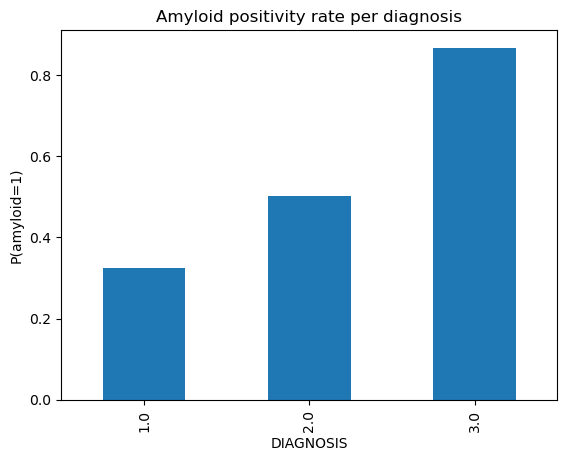


=== TAU + DX ===
Shape: (2100, 340)

Tau SUVR stats by diagnosis:
               mean       std    min    max
DIAGNOSIS                                  
1.0        1.208876  0.131443  0.916  2.165
2.0        1.333206  0.298761  0.960  2.832
3.0        1.714172  0.480966  1.074  3.833


<Figure size 640x480 with 0 Axes>

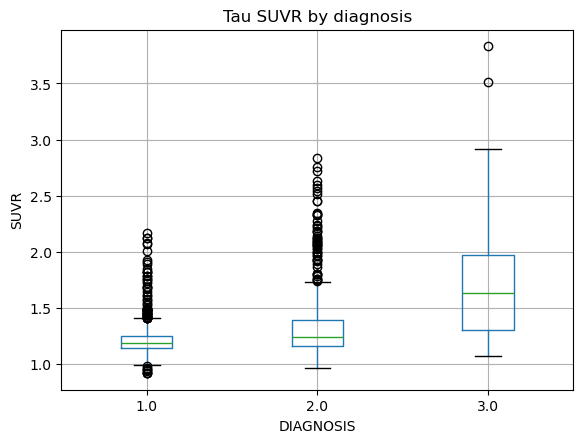

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. CLEAN DXSUM (diagnosis table)
# ============================================================
DXSUM = pd.read_csv('DXSUM.csv')
dx = DXSUM.copy()
# keep only relevant columns (adjust names if needed)
dx = dx[["RID", "VISCODE2", "DIAGNOSIS"]].dropna()
print("DXSUM distribution:")
print(dx["DIAGNOSIS"].value_counts())
# ============================================================
# 2. MERGE WITH AMYLOID
# ============================================================
amy_dx = amy_clean.merge(dx, on=["RID", "VISCODE2"], how="inner")
print("\n=== AMYLOID + DX ===")
print("Shape:", amy_dx.shape)
print("\nAmyloid status by diagnosis:")
print(pd.crosstab(amy_dx["DIAGNOSIS"], amy_dx["AMYLOID_STATUS"], normalize="index"))

# plot
amy_dx.groupby("DIAGNOSIS")["AMYLOID_STATUS"].mean().plot(kind="bar")
plt.title("Amyloid positivity rate per diagnosis")
plt.ylabel("P(amyloid=1)")
plt.show()

# ============================================================
# 3. MERGE WITH TAU
# ============================================================
tau_dx = tau_clean.merge(dx, on=["RID", "VISCODE2"], how="inner")
print("\n=== TAU + DX ===")
print("Shape:", tau_dx.shape)
print("\nTau SUVR stats by diagnosis:")
print(tau_dx.groupby("DIAGNOSIS")["META_TEMPORAL_SUVR"].describe()[["mean","std","min","max"]])

# plot SUVR distribution per diagnosis
plt.figure()
tau_dx.boxplot(column="META_TEMPORAL_SUVR", by="DIAGNOSIS")
plt.title("Tau SUVR by diagnosis")
plt.suptitle("")
plt.ylabel("SUVR")
plt.show()

In [41]:
demo = PTDEMOG = pd.read_csv("PTDEMOG.csv")[["PTID", "VISCODE2", "PTGENDER", "PTDOBYY"]]
# missing DOB stats
print("Missing PTDOBYY rows:", demo["PTDOBYY"].isna().sum())

print("\nMissing PTDOBYY by patient:", demo.groupby("PTID")["PTDOBYY"].apply(lambda x: x.isna().all()).sum())

print("\nPatients with at least one valid DOB:", demo.groupby("PTID")["PTDOBYY"].apply(lambda x: x.notna().any()).sum())

Missing PTDOBYY rows: 189

Missing PTDOBYY by patient: 12

Patients with at least one valid DOB: 4856


In [42]:
# ensure numeric
demo["PTDOBYY"] = pd.to_datetime(demo["PTDOBYY"], errors="coerce").dt.year

# score completeness per row
demo["score"] = (
    demo["PTDOBYY"].notna().astype(int) +
    demo["PTGENDER"].notna().astype(int)
)

# keep best row per PTID
demo_clean = (
    demo.sort_values(["PTID", "score"], ascending=[True, False])
        .drop_duplicates("PTID")
        .drop(columns=["score"])
)
demo_clean = demo_clean[['PTID', 'PTGENDER', 'PTDOBYY']]
print(demo_clean.columns)
len(demo_clean)

Index(['PTID', 'PTGENDER', 'PTDOBYY'], dtype='object')


4868

In [43]:
demo_clean.head(1)

,PTID,PTGENDER,PTDOBYY
340,002_S_0295,1.0,1921.0


In [44]:
print(demo_clean.isna().sum())

PTID         0
PTGENDER    10
PTDOBYY     12
dtype: int64


In [45]:
demo_clean = demo_clean.dropna(subset=["PTGENDER", "PTDOBYY"])
print(demo_clean.columns)
len(demo_clean)

Index(['PTID', 'PTGENDER', 'PTDOBYY'], dtype='object')


4856

In [46]:
print(demo["PTDOBYY"].head())   # likely 1936, 1945, ... (good)


0    1931.0
1    1944.0
2    1924.0
3    1938.0
4    1931.0
Name: PTDOBYY, dtype: float64


In [47]:
# ============================================================
# 4. ATTACH DEMO + AGE-AT-SCAN + DX TO EACH SCAN TABLE
# ============================================================
def add_features(scan_df):
    out = scan_df.merge(demo_clean, on="PTID", how="left")          # gender + birth year (per patient)
    out = out.merge(dx, on=["RID", "VISCODE2"], how="left")         # diagnosis (per visit)
    # age at the scan date: scan year minus birth year
    scan_year = pd.to_datetime(out["SCANDATE"], errors="coerce").dt.year
    out["AGE_AT_SCAN"] = scan_year - out["PTDOBYY"]
    # readable gender (ADNI: 1 = Male, 2 = Female)
    out["SEX"] = out["PTGENDER"].map({1: "M", 2: "F"})
    return out

amy_feat = add_features(amy_clean)
tau_feat = add_features(tau_clean)

# sanity checks
for name, df in [("AMYLOID", amy_feat), ("TAU", tau_feat)]:
    print(f"\n=== {name} + DEMO + DX ===")
    print("Shape:", df.shape)
    print("Age at scan:", df["AGE_AT_SCAN"].describe()[["mean", "min", "max"]].round(1).to_dict())
    print("Sex counts:", df["SEX"].value_counts(dropna=False).to_dict())
    print("Missing diagnosis:", df["DIAGNOSIS"].isna().sum())


=== AMYLOID + DEMO + DX ===
Shape: (3292, 349)
Age at scan: {'mean': 75.1, 'min': 55.0, 'max': 98.0}
Sex counts: {'F': 1662, 'M': 1630}
Missing diagnosis: 29

=== TAU + DEMO + DX ===
Shape: (2117, 344)
Age at scan: {'mean': 74.1, 'min': 51.0, 'max': 96.0}
Sex counts: {'F': 1144, 'M': 973}
Missing diagnosis: 17


In [48]:
# ============================================================
# 5. KEEP ONLY NEEDED COLUMNS (IDs + features + target)
# ============================================================
ID_COLS      = ["PTID", "RID", "VISCODE2", "SCANDATE", "LONIUID"]   # tracking / merge keys
FEATURE_COLS = ["AGE_AT_SCAN", "SEX", "DIAGNOSIS"]                  # demo + diagnosis

amy_final = amy_feat[ID_COLS + FEATURE_COLS + ["AMYLOID_STATUS"]].copy()       # classification target
tau_final = tau_feat[ID_COLS + FEATURE_COLS + ["META_TEMPORAL_SUVR"]].copy()   # regression target

print("Amyloid final:", amy_final.shape, "->", list(amy_final.columns))
print("Tau final:    ", tau_final.shape, "->", list(tau_final.columns))

Amyloid final: (3292, 9) -> ['PTID', 'RID', 'VISCODE2', 'SCANDATE', 'LONIUID', 'AGE_AT_SCAN', 'SEX', 'DIAGNOSIS', 'AMYLOID_STATUS']
Tau final:     (2117, 9) -> ['PTID', 'RID', 'VISCODE2', 'SCANDATE', 'LONIUID', 'AGE_AT_SCAN', 'SEX', 'DIAGNOSIS', 'META_TEMPORAL_SUVR']


In [49]:
amy_final.head(1)

,PTID,RID,VISCODE2,SCANDATE,LONIUID,AGE_AT_SCAN,SEX,DIAGNOSIS,AMYLOID_STATUS
0,011_S_0021,21,m60,2010-10-08,1594517,77.0,F,1.0,0.0


In [50]:
tau_final.head(1)

,PTID,RID,VISCODE2,SCANDATE,LONIUID,AGE_AT_SCAN,SEX,DIAGNOSIS,META_TEMPORAL_SUVR
0,011_S_0021,21,m144,2018-02-02,1594604,85.0,F,1.0,1.239


In [51]:
# ============================================================
# 6. CHECK EMPTY / MISSING VALUES
# ============================================================
for name, df in [("AMYLOID", amy_final), ("TAU", tau_final)]:
    print(f"\n=== {name} ({len(df)} rows) ===")
    na = df.isna().sum()
    print(na[na > 0] if na.sum() else "No missing values")
    print("Rows with any NaN:", df.isna().any(axis=1).sum())


=== AMYLOID (3292 rows) ===
DIAGNOSIS    29
dtype: int64
Rows with any NaN: 29

=== TAU (2117 rows) ===
DIAGNOSIS    17
dtype: int64
Rows with any NaN: 17


In [52]:
# =========================
# TARGET DISTRIBUTIONS
# =========================

print("AMYLOID TARGET (AMYLOID_STATUS)")
print(amy_final["AMYLOID_STATUS"].value_counts())
print("\nProportions:")
print(amy_final["AMYLOID_STATUS"].value_counts(normalize=True))

print("\n\nTAU TARGET (META_TEMPORAL_SUVR)")
print(tau_final["META_TEMPORAL_SUVR"].describe())

print("\nTau histogram bins:")
print(pd.cut(tau_final["META_TEMPORAL_SUVR"], bins=5).value_counts().sort_index())

AMYLOID TARGET (AMYLOID_STATUS)
AMYLOID_STATUS
0.0    1754
1.0    1538
Name: count, dtype: int64

Proportions:
AMYLOID_STATUS
0.0    0.532807
1.0    0.467193
Name: proportion, dtype: float64


TAU TARGET (META_TEMPORAL_SUVR)
count    2117.000000
mean        1.304531
std         0.296811
min         0.916000
25%         1.151000
50%         1.212000
75%         1.316000
max         3.833000
Name: META_TEMPORAL_SUVR, dtype: float64

Tau histogram bins:
META_TEMPORAL_SUVR
(0.913, 1.499]    1830
(1.499, 2.083]     209
(2.083, 2.666]      63
(2.666, 3.25]       13
(3.25, 3.833]        2
Name: count, dtype: int64


In [53]:
amy_final.to_csv("amy_dataset.csv", index=False)

# Correct IDs

In [54]:
correct_ids = pd.read_csv("Tables_PET/correct_pet_id.csv")
correct_ids = correct_ids.rename(columns={'Study Date': 'SCANDATE', 'Subject ID':'PTID', 'Image ID':'LONIUID', 'Description':'IMAGE_DESCRIPTION'})
correct_ids["SCANDATE"] = pd.to_datetime(correct_ids["SCANDATE"], errors="coerce")

In [55]:
# ---- align SCANDATE dtype on the scan tables (string -> datetime) ----
amy_final["SCANDATE"] = pd.to_datetime(amy_final["SCANDATE"], errors="coerce")
tau_final["SCANDATE"] = pd.to_datetime(tau_final["SCANDATE"], errors="coerce")

# ---- split correct_ids into the amyloid-relevant and tau-relevant rows ----
# a row in correct_ids is "amyloid" if its (PTID, SCANDATE) appears in amy_final, etc.
amy_keys = set(map(tuple, amy_final[["PTID", "SCANDATE"]].dropna().values))
tau_keys = set(map(tuple, tau_final[["PTID", "SCANDATE"]].dropna().values))

correct_ids["_key"] = list(map(tuple, correct_ids[["PTID", "SCANDATE"]].values))
amy_ids = correct_ids[correct_ids["_key"].isin(amy_keys)].copy()
tau_ids = correct_ids[correct_ids["_key"].isin(tau_keys)].copy()

# ---- duplicate check on (PTID, SCANDATE), separately ----
for name, df in [("AMYLOID ids", amy_ids), ("TAU ids", tau_ids)]:
    dup_mask = df.duplicated(subset=["PTID", "SCANDATE"], keep=False)
    print(f"\n=== {name}: {len(df)} rows, {dup_mask.sum()} in duplicate (PTID,SCANDATE) groups ===")
    if dup_mask.any():
        print(df[dup_mask]
              .sort_values(["PTID", "SCANDATE"])
              [["PTID", "SCANDATE", "LONIUID", "IMAGE_DESCRIPTION"]]
              .head(20))


=== AMYLOID ids: 3479 rows, 380 in duplicate (PTID,SCANDATE) groups ===
           PTID   SCANDATE  LONIUID                     IMAGE_DESCRIPTION
609  005_S_2390 2013-08-14   385603      20 min Emission - Ite Early AV45
610  005_S_2390 2013-08-14   385604       20 min 3D AV45 - Iter(Brain Mod
615  005_S_4168 2013-10-04   393389      20 min Emission - Ite Early AV45
616  005_S_4168 2013-10-04   393390       20 min 3D AV45 - Iter(Brain Mod
626  005_S_4185 2013-09-30   392979      20 min Emission - Ite Early AV45
627  005_S_4185 2013-09-30   392980       20 min 3D AV45 - Iter(Brain Mod
637  005_S_5119 2013-04-25   368943       20 min 3D AV45 - Iter(Brain Mod
638  005_S_5119 2013-04-25   368944      20 min Emission - Ite Early AV45
661  006_S_0498 2013-11-04   398012        Adni Early AV45 0-20min 4i/16s
662  006_S_0498 2013-11-04   398013              Adni AV45 4 X 300 4i/16s
666  006_S_0498 2020-01-13  1275261  Brain_ADNI3_EarlyFrames_LM (AC) AV45
667  006_S_0498 2020-01-13  1275262    

In [56]:
# ---- drop ALL copies of any duplicated (PTID, SCANDATE) ----
amy_ids_unique = amy_ids[~amy_ids.duplicated(subset=["PTID", "SCANDATE"], keep=False)].copy()
tau_ids_unique = tau_ids[~tau_ids.duplicated(subset=["PTID", "SCANDATE"], keep=False)].copy()

for name, before, after in [("AMYLOID ids", amy_ids, amy_ids_unique),
                            ("TAU ids",     tau_ids, tau_ids_unique)]:
    removed = len(before) - len(after)
    print(f"{name}: {len(before)} -> {len(after)}  (removed {removed} rows in dup groups)")

AMYLOID ids: 3479 -> 3099  (removed 380 rows in dup groups)
TAU ids: 2116 -> 2116  (removed 0 rows in dup groups)


In [57]:
# ============================================================
# Build final amy table with TWO id columns:
#   image_id_1 = LONIUID from the 6MM table (amy_final)
#   image_id_2 = Image ID from the collection we downloaded (correct_ids)
# joined on (PTID, SCANDATE)
# ============================================================

# amy_ids_unique has the collection IDs (one per PTID+SCANDATE)
amy_ids_unique["SCANDATE"] = pd.to_datetime(amy_ids_unique["SCANDATE"], errors="coerce")

amy_table = amy_final.rename(columns={"LONIUID": "image_id_1"}).merge(
    amy_ids_unique[["PTID", "SCANDATE", "LONIUID"]].rename(columns={"LONIUID": "image_id_2"}),
    on=["PTID", "SCANDATE"], how="inner"
)

print("amy_table shape:", amy_table.shape)
print("columns:", list(amy_table.columns))
amy_table.head(3)

amy_table shape: (3100, 10)
columns: ['PTID', 'RID', 'VISCODE2', 'SCANDATE', 'image_id_1', 'AGE_AT_SCAN', 'SEX', 'DIAGNOSIS', 'AMYLOID_STATUS', 'image_id_2']


,PTID,RID,VISCODE2,SCANDATE,image_id_1,AGE_AT_SCAN,SEX,DIAGNOSIS,AMYLOID_STATUS,image_id_2
0,011_S_0021,21,m60,2010-10-08,1594517,77.0,F,1.0,0.0,196276
1,011_S_0021,21,m84,2012-10-03,1594530,79.0,F,1.0,0.0,338095
2,011_S_0021,21,m120,2015-11-05,1594602,82.0,F,1.0,0.0,544566


# Sampling 

In [60]:
# ============================================================
# Sample the rows corresponding to the 1499 images we actually have
# (match on image_id_2 = the downloaded collection IDs in pp5_suvr/)
# ============================================================
import re
from pathlib import Path

# the I-numbers we actually preprocessed
have_ids = {re.search(r"(I\d+)", f.name).group(1)
            for f in Path("data/pp5_suvr").glob("*.nii.gz")}
print("preprocessed images on disk:", len(have_ids))

# normalize image_id_2 to string form matching the filenames (e.g. "I998028")
amy_table["image_id_2_str"] = amy_table["image_id_2"].astype(str)
amy_table["image_id_2_str"] = amy_table["image_id_2_str"].apply(
    lambda x: x if x.startswith("I") else f"I{x}")

# keep only rows we have images for
amy_sample = amy_table[amy_table["image_id_2_str"].isin(have_ids)].copy()
print("matched rows (have image + label):", len(amy_sample))

# any images on disk with no matching label row?
matched = set(amy_sample["image_id_2_str"])
missing = have_ids - matched
print("images on disk with NO label row:", len(missing))
if missing: print("  examples:", list(missing)[:10])

# ---- label distribution ----
print("\n=== AMYLOID_STATUS distribution (sampled set) ===")
print(amy_sample["AMYLOID_STATUS"].value_counts())
print("\nproportions:")
print(amy_sample["AMYLOID_STATUS"].value_counts(normalize=True).round(3))

preprocessed images on disk: 1499
matched rows (have image + label): 1499
images on disk with NO label row: 0

=== AMYLOID_STATUS distribution (sampled set) ===
AMYLOID_STATUS
0.0    790
1.0    709
Name: count, dtype: int64

proportions:
AMYLOID_STATUS
0.0    0.527
1.0    0.473
Name: proportion, dtype: float64


In [61]:
amy_sample.to_csv("amy_dataset_final.csv", index=False)
print("saved", len(amy_sample), "rows")

saved 1499 rows


In [54]:
all_images.head()

,LONIUID,subject_id,phase,study_id,modality,image_type,image_visit,image_date,IMAGE_DESCRIPTION,upload_date,file_format,structure,laterality
0,78018,037_S_1421,ADNI 1,13296,PET,Pre-processed,bl,2007-10-15,"PIB Coreg, Avg, Std Img and Vox Siz, Uniform R...",2007-10-17,DICOM,Brain,Both
1,78017,037_S_1421,ADNI 1,13296,PET,Pre-processed,bl,2007-10-15,"PIB Coreg, Avg, Standardized Image and Voxel Size",2007-10-17,DICOM,Brain,Both
2,77805,037_S_1421,ADNI 1,13296,PET,Original,bl,2007-10-15,ADNI PET Brain PIB,2007-10-16,DICOM,Brain,Both
3,70846,037_S_1421,ADNI 1,11613,MRI,Original,sc,2007-08-27,"Head,3-P,2D,LOCALIZER",2007-08-29,DICOM,Brain,Both
4,70847,037_S_1421,ADNI 1,11613,MRI,Original,sc,2007-08-27,"Head,3-P,2D,LOCALIZER",2007-08-29,DICOM,Brain,Both


# Cross Validation Splits

In [62]:
import json
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold

SEED = 42
N_FOLDS = 7
VAL_FRACTION_OF_TRAIN = 0.125
RESULTS_DIR = Path("cv_splits"); RESULTS_DIR.mkdir(exist_ok=True)
SPLITS_FILE = RESULTS_DIR / "amyloid_cv_splits.json"

In [63]:
labels = amy_sample.copy()
labels["AMYLOID_STATUS"] = labels["AMYLOID_STATUS"].astype(int)

In [64]:
if SPLITS_FILE.exists():
    with open(SPLITS_FILE) as f:
        splits = json.load(f)
    print(f"✓ Loaded existing splits from {SPLITS_FILE}")
else:
    print("Computing new patient-level CV splits...")

    # one label per patient (mode) for stratification
    patient_status = (labels.groupby("PTID")["AMYLOID_STATUS"]
                      .agg(lambda x: x.mode().iloc[0]).reset_index())
    patients = patient_status["PTID"].values
    status   = patient_status["AMYLOID_STATUS"].values
    print(f"  Total patients: {len(patients)} (images: {len(labels)})")

    # hold out 10% of patients for inference — never touched during CV
    cv_patients, holdout_patients, cv_status, _ = train_test_split(
        patients, status, test_size=0.10, stratify=status, random_state=SEED)
    print(f"  CV patients: {len(cv_patients)}  |  Holdout patients: {len(holdout_patients)}")

    holdout_df = labels[labels["PTID"].isin(holdout_patients)]
    holdout_record = {
        "holdout_patients": holdout_patients.tolist(),
        "image_ids":        holdout_df["image_id_2_str"].tolist(),
        "labels":           holdout_df["AMYLOID_STATUS"].tolist(),
        "positive_rate":    float(holdout_df["AMYLOID_STATUS"].mean()),
        "n_total":          int(len(holdout_df)),
        "n_patients":       int(len(holdout_patients)),
    }
    with open(RESULTS_DIR / "holdout_inference_set.json", "w") as f:
        json.dump(holdout_record, f, indent=2)
    print(f"  ✓ Holdout saved: {holdout_record['n_patients']} patients, "
          f"{holdout_record['n_total']} images, "
          f"{100*holdout_record['positive_rate']:.1f}% positive")

    # 7-fold CV on remaining 90%
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    splits = []
    for fold_idx, (trainval_idx, test_idx) in enumerate(skf.split(cv_patients, cv_status)):
        test_patients     = cv_patients[test_idx].tolist()
        trainval_patients = cv_patients[trainval_idx]
        trainval_status   = cv_status[trainval_idx]

        val_skf = StratifiedKFold(n_splits=int(1 / VAL_FRACTION_OF_TRAIN),
                                  shuffle=True, random_state=SEED + fold_idx)
        train_idx_inner, val_idx_inner = next(val_skf.split(trainval_patients, trainval_status))
        splits.append({
            "fold":           fold_idx,
            "train_patients": trainval_patients[train_idx_inner].tolist(),
            "val_patients":   trainval_patients[val_idx_inner].tolist(),
            "test_patients":  test_patients,
        })

    with open(SPLITS_FILE, "w") as f:
        json.dump(splits, f, indent=2)
    print(f"✓ Saved splits to {SPLITS_FILE}")

Computing new patient-level CV splits...
  Total patients: 974 (images: 1499)
  CV patients: 876  |  Holdout patients: 98
  ✓ Holdout saved: 98 patients, 158 images, 50.0% positive
✓ Saved splits to cv_splits/amyloid_cv_splits.json


In [65]:
# leakage check
for s in splits:
    assert not (set(s["train_patients"]) & set(s["val_patients"]))
    assert not (set(s["train_patients"]) & set(s["test_patients"]))
    assert not (set(s["val_patients"])   & set(s["test_patients"]))
print("\n✓ No patient leakage")


✓ No patient leakage


In [68]:
print("\nAMYLOID_STATUS positive rate per fold (train sets):")
for s in splits:
    te = labels[labels["PTID"].isin(s["train_patients"])]
    print(f"  Fold {s['fold']}: {100*te['AMYLOID_STATUS'].mean():.1f}%  (n={len(te)})")


AMYLOID_STATUS positive rate per fold (train sets):
  Fold 0: 47.3%  (n=1005)
  Fold 1: 46.6%  (n=1018)
  Fold 2: 48.1%  (n=1001)
  Fold 3: 46.8%  (n=1003)
  Fold 4: 46.3%  (n=1006)
  Fold 5: 46.8%  (n=993)
  Fold 6: 46.6%  (n=1003)


In [69]:
print("\nAMYLOID_STATUS positive rate per fold (test sets):")
for s in splits:
    te = labels[labels["PTID"].isin(s["test_patients"])]
    print(f"  Fold {s['fold']}: {100*te['AMYLOID_STATUS'].mean():.1f}%  (n={len(te)})")


AMYLOID_STATUS positive rate per fold (test sets):
  Fold 0: 47.2%  (n=195)
  Fold 1: 48.8%  (n=168)
  Fold 2: 47.0%  (n=200)
  Fold 3: 46.0%  (n=198)
  Fold 4: 44.9%  (n=187)
  Fold 5: 47.3%  (n=201)
  Fold 6: 47.9%  (n=192)


In [70]:
print("\nAMYLOID_STATUS positive rate per fold (val sets):")
for s in splits:
    te = labels[labels["PTID"].isin(s["val_patients"])]
    print(f"  Fold {s['fold']}: {100*te['AMYLOID_STATUS'].mean():.1f}%  (n={len(te)})")


AMYLOID_STATUS positive rate per fold (val sets):
  Fold 0: 44.7%  (n=141)
  Fold 1: 47.7%  (n=155)
  Fold 2: 39.3%  (n=140)
  Fold 3: 50.0%  (n=140)
  Fold 4: 54.1%  (n=148)
  Fold 5: 47.6%  (n=147)
  Fold 6: 48.6%  (n=146)
